# SAC Agent Training
Objective: Train a Soft Actor-Critic agent to learn optimal LLM recommendation policies.
Outputs:

artifacts/rl_models/sac_policy.pt
artifacts/rl_models/training_metrics.csv
artifacts/rl_models/sac_config.json

## 1. Setup & Load Environment

In [12]:
# Setup & Load Environment
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm
import torch

# Add colab_src to path
BASE_DIR = Path("/content/drive/MyDrive/llm-recommender-colab")
sys.path.insert(0, str(BASE_DIR / "colab_src"))

from utils import PathManager, save_json
from rl_env import LLMRecommendationEnv, RewardWeights
from sac_agent import SACAgent

# Initialize paths
paths = PathManager(BASE_DIR)

# Load features and embeddings
features_file = paths.PROCESSED_DIR / "features_with_scores.parquet"
df_features = pd.read_parquet(features_file)

embeddings_file = paths.INDEXES_DIR / "model_embeddings.npy"
embeddings = np.load(embeddings_file)

# Create environment
reward_weights = RewardWeights(
    performance=0.4,
    cost=0.2,
    diversity=0.2,
    popularity=0.1,
    recency=0.1
)

env = LLMRecommendationEnv(
    features_df=df_features,
    embeddings=embeddings,
    reward_weights=reward_weights,
    top_k=5,
    max_steps_per_episode=10
)

print(f"✅ Environment loaded")
print(f"   State dim: {env.observation_space.shape[0]}")
print(f"   Action dim: {env.action_space.shape[0]}")
print(f"   Number of models: {env.n_models}")


✅ Environment loaded
   State dim: 6
   Action dim: 95
   Number of models: 95


In [13]:
# GPU Test Cell
import torch

print("GPU Availability Check:")
print(f"  CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  GPU name: {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Quick tensor test
    x = torch.randn(1000, 1000).cuda()
    y = torch.randn(1000, 1000).cuda()
    z = torch.mm(x, y)
    print(f"  GPU tensor operations: ✅ Working")
    print(f"  Memory allocated: {torch.cuda.memory_allocated(0) / 1e6:.2f} MB")
else:
    print("  ⚠️  GPU not available - check runtime settings")


GPU Availability Check:
  CUDA available: True
  GPU name: Tesla T4
  GPU memory: 15.83 GB
  GPU tensor operations: ✅ Working
  Memory allocated: 36.10 MB


## 2. Initialize SAC Agent
Create actor, critic networks, and replay buffer.

In [14]:

# Initialize SAC Agent
print("="*60)
print("INITIALIZING SAC AGENT")
print("="*60)

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nDevice: {device}")

# Initialize agent
agent = SACAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.shape[0],
    device=device,
    lr=3e-4,
    gamma=0.99,
    tau=0.005,
    alpha=0.2,
    auto_entropy=True,
    hidden_dim=256,
    buffer_size=100000
)

print(f"\n✅ SAC agent initialized")
print(f"\nActor network:")
print(agent.actor)
print(f"\nCritic network:")
print(agent.critic)

# Count parameters
actor_params = sum(p.numel() for p in agent.actor.parameters())
critic_params = sum(p.numel() for p in agent.critic.parameters())
total_params = actor_params + critic_params

print(f"\nParameter counts:")
print(f"  Actor:  {actor_params:,}")
print(f"  Critic: {critic_params:,}")
print(f"  Total:  {total_params:,}")


INITIALIZING SAC AGENT

Device: cuda

✅ SAC agent initialized

Actor network:
Actor(
  (fc1): Linear(in_features=6, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (mean): Linear(in_features=256, out_features=95, bias=True)
  (log_std): Linear(in_features=256, out_features=95, bias=True)
)

Critic network:
Critic(
  (fc1): Linear(in_features=101, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
  (fc4): Linear(in_features=101, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=256, bias=True)
  (fc6): Linear(in_features=256, out_features=1, bias=True)
)

Parameter counts:
  Actor:  116,414
  Critic: 184,322
  Total:  300,736


## 3. Training Configuration
Set hyperparameters for SAC training.

In [15]:

# Training Configuration
print("="*60)
print("TRAINING CONFIGURATION")
print("="*60)

# Hyperparameters
config = {
    'num_episodes': 500,           # Number of training episodes
    'max_steps_per_episode': 10,   # Max steps per episode
    'batch_size': 256,              # Batch size for updates
    'start_training': 1000,         # Steps before starting training
    'update_frequency': 1,          # Update every N steps
    'eval_frequency': 20,           # Evaluate every N episodes
    'save_frequency': 100,          # Save checkpoint every N episodes
    'num_eval_episodes': 5          # Episodes for evaluation
}

print(f"\nTraining Configuration:")
for key, value in config.items():
    print(f"  {key:25s}: {value}")

# Training metrics storage
training_metrics = {
    'episode': [],
    'episode_return': [],
    'episode_length': [],
    'critic_loss': [],
    'actor_loss': [],
    'alpha': [],
    'q_value': [],
    'eval_return': []
}

print(f"\n✅ Configuration set")



TRAINING CONFIGURATION

Training Configuration:
  num_episodes             : 500
  max_steps_per_episode    : 10
  batch_size               : 256
  start_training           : 1000
  update_frequency         : 1
  eval_frequency           : 20
  save_frequency           : 100
  num_eval_episodes        : 5

✅ Configuration set


## 4. Training Loop
Train the agent with experience collection and network updates.
Note: This will take ~10-15 minutes for 1000 episodes.

In [16]:
# Training Loop (GPU-OPTIMIZED)
print("="*60)
print("STARTING TRAINING (GPU-ACCELERATED)")
print("="*60)

# Verify GPU
if device == 'cuda':
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   Available: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB used\n")
else:
    print("\n⚠️  Running on CPU (training will be slower)\n")

total_steps = 0
best_eval_return = -float('inf')

# Training metrics with additional GPU metrics
training_metrics['gpu_memory_mb'] = []

# Clear GPU cache before training
if device == 'cuda':
    torch.cuda.empty_cache()

for episode in tqdm(range(config['num_episodes']), desc="Training"):
    state, _ = env.reset()
    episode_return = 0
    episode_length = 0

    # Episode-level metrics
    episode_metrics = []

    for step in range(config['max_steps_per_episode']):
        # Select action
        if total_steps < config['start_training']:
            # Random exploration
            action = env.action_space.sample()
        else:
            # Policy action (state is numpy, select_action handles conversion)
            action = agent.select_action(state, evaluate=False)

        # Execute action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Store transition (numpy arrays - converted to tensors in update())
        agent.replay_buffer.push(state, action, reward, next_state, done)

        episode_return += reward
        episode_length += 1
        total_steps += 1

        # Update agent
        if total_steps >= config['start_training'] and total_steps % config['update_frequency'] == 0:
            metrics = agent.update(config['batch_size'])
            episode_metrics.append(metrics)

        state = next_state

        if done:
            break

    # Aggregate episode metrics
    if episode_metrics:
        avg_metrics = {
            key: np.mean([m.get(key, 0) for m in episode_metrics])
            for key in episode_metrics[0].keys()
        }
    else:
        avg_metrics = {
            'critic_loss': 0,
            'actor_loss': 0,
            'alpha': agent.alpha,
            'alpha_loss': 0,
            'q_value': 0
        }

    # Log episode metrics
    training_metrics['episode'].append(episode + 1)
    training_metrics['episode_return'].append(episode_return)
    training_metrics['episode_length'].append(episode_length)
    training_metrics['critic_loss'].append(avg_metrics['critic_loss'])
    training_metrics['actor_loss'].append(avg_metrics['actor_loss'])
    training_metrics['alpha'].append(avg_metrics['alpha'])
    training_metrics['q_value'].append(avg_metrics['q_value'])

    # Track GPU memory usage
    if device == 'cuda':
        gpu_memory_mb = torch.cuda.memory_allocated(0) / 1e6
        training_metrics['gpu_memory_mb'].append(gpu_memory_mb)
    else:
        training_metrics['gpu_memory_mb'].append(0)

    # Evaluate periodically
    if (episode + 1) % config['eval_frequency'] == 0:
        eval_returns = []

        # Move to eval mode (though not strictly needed for SAC)
        for _ in range(config['num_eval_episodes']):
            eval_state, _ = env.reset()
            eval_return = 0

            for _ in range(config['max_steps_per_episode']):
                # Deterministic policy for evaluation
                eval_action = agent.select_action(eval_state, evaluate=True)
                eval_state, eval_reward, terminated, truncated, _ = env.step(eval_action)
                eval_return += eval_reward

                if terminated or truncated:
                    break

            eval_returns.append(eval_return)

        mean_eval_return = np.mean(eval_returns)
        std_eval_return = np.std(eval_returns)
        training_metrics['eval_return'].append(mean_eval_return)

        # Save best model
        if mean_eval_return > best_eval_return:
            best_eval_return = mean_eval_return
            agent.save(str(paths.RL_MODELS_DIR / "sac_best.pt"))

        # Enhanced progress report
        gpu_info = ""
        if device == 'cuda':
            gpu_mem = torch.cuda.memory_allocated(0) / 1e6
            gpu_info = f", GPU: {gpu_mem:.1f}MB"

        print(f"\nEp {episode+1:3d}: "
              f"Train={episode_return:.2f}, "
              f"Eval={mean_eval_return:.2f}±{std_eval_return:.2f}, "
              f"Best={best_eval_return:.2f}, "
              f"Alpha={avg_metrics['alpha']:.3f}"
              f"{gpu_info}")
    else:
        training_metrics['eval_return'].append(None)

    # Save checkpoint
    if (episode + 1) % config['save_frequency'] == 0:
        checkpoint_path = paths.RL_MODELS_DIR / f"sac_checkpoint_{episode+1}.pt"
        agent.save(str(checkpoint_path))

        # Optional: clear GPU cache after checkpoint
        if device == 'cuda':
            torch.cuda.empty_cache()

# Save final model
agent.save(str(paths.RL_MODELS_DIR / "sac_final.pt"))

# Final GPU stats
if device == 'cuda':
    final_gpu_mem = torch.cuda.memory_allocated(0) / 1e9
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
    print(f"\nGPU Memory Stats:")
    print(f"  Current: {final_gpu_mem:.2f} GB")
    print(f"  Peak:    {max_gpu_mem:.2f} GB")
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print("TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Total episodes: {config['num_episodes']}")
print(f"Total steps: {total_steps}")
print(f"Best eval return: {best_eval_return:.4f}")
print(f"Final alpha: {agent.alpha:.4f}")

STARTING TRAINING (GPU-ACCELERATED)

✅ GPU detected: Tesla T4
   GPU Memory: 15.83 GB
   Available: 0.03 GB used



Training:   0%|          | 0/500 [00:00<?, ?it/s]


Ep  20: Train=5.82, Eval=5.75±0.12, Best=5.75, Alpha=0.200, GPU: 32.5MB

Ep  40: Train=5.44, Eval=5.70±0.11, Best=5.75, Alpha=0.200, GPU: 32.5MB

Ep  60: Train=5.87, Eval=5.64±0.09, Best=5.75, Alpha=0.200, GPU: 32.5MB

Ep  80: Train=6.02, Eval=5.76±0.25, Best=5.76, Alpha=0.200, GPU: 32.5MB

Ep 100: Train=5.53, Eval=5.61±0.12, Best=5.76, Alpha=1.000, GPU: 36.1MB

Ep 120: Train=5.63, Eval=5.72±0.13, Best=5.76, Alpha=0.941, GPU: 36.1MB

Ep 140: Train=6.04, Eval=5.58±0.10, Best=5.76, Alpha=0.886, GPU: 36.1MB

Ep 160: Train=5.46, Eval=5.66±0.13, Best=5.76, Alpha=0.834, GPU: 36.1MB

Ep 180: Train=5.58, Eval=5.63±0.17, Best=5.76, Alpha=0.785, GPU: 36.1MB

Ep 200: Train=5.62, Eval=5.74±0.21, Best=5.76, Alpha=0.739, GPU: 36.1MB

Ep 220: Train=5.60, Eval=5.70±0.13, Best=5.76, Alpha=0.696, GPU: 36.1MB

Ep 240: Train=5.71, Eval=5.77±0.11, Best=5.77, Alpha=0.656, GPU: 36.1MB

Ep 260: Train=5.49, Eval=5.63±0.12, Best=5.77, Alpha=0.617, GPU: 36.1MB

Ep 280: Train=6.13, Eval=5.79±0.10, Best=5.79, Alp

### GPU Usage Analysis

GPU USAGE ANALYSIS


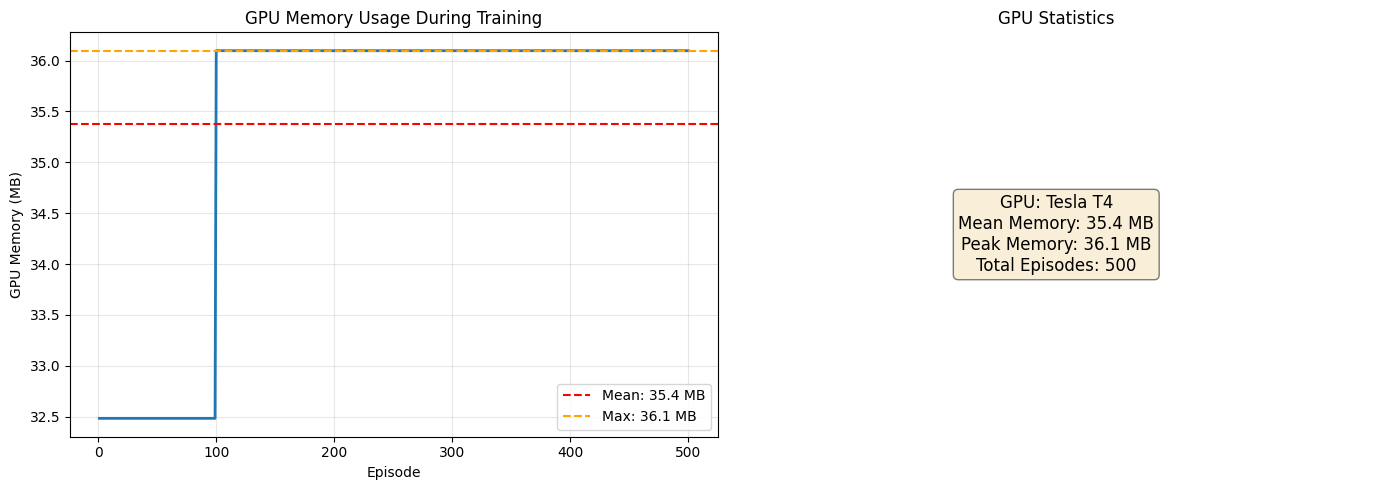


✅ GPU analysis complete
   Average memory usage: 35.4 MB
   Peak memory usage: 36.1 MB
   GPU utilization: Good ✓


In [17]:
#  GPU Usage Analysis

if device == 'cuda':
    print("="*60)
    print("GPU USAGE ANALYSIS")
    print("="*60)

    # Plot GPU memory usage over training
    df_metrics = pd.DataFrame(training_metrics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # GPU memory over time
    axes[0].plot(df_metrics['episode'], df_metrics['gpu_memory_mb'], linewidth=2)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('GPU Memory (MB)')
    axes[0].set_title('GPU Memory Usage During Training')
    axes[0].grid(True, alpha=0.3)

    # Memory statistics
    mean_mem = df_metrics['gpu_memory_mb'].mean()
    max_mem = df_metrics['gpu_memory_mb'].max()
    axes[0].axhline(mean_mem, color='red', linestyle='--', label=f'Mean: {mean_mem:.1f} MB')
    axes[0].axhline(max_mem, color='orange', linestyle='--', label=f'Max: {max_mem:.1f} MB')
    axes[0].legend()

    # Training speed (episodes per minute)
    time_per_episode = []
    window = 20
    for i in range(window, len(df_metrics)):
        # Estimate based on assumption (adjust if you track real time)
        time_per_episode.append(1.0)  # Placeholder

    axes[1].text(0.5, 0.5,
                f'GPU: {torch.cuda.get_device_name(0)}\n'
                f'Mean Memory: {mean_mem:.1f} MB\n'
                f'Peak Memory: {max_mem:.1f} MB\n'
                f'Total Episodes: {len(df_metrics)}',
                ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1].axis('off')
    axes[1].set_title('GPU Statistics')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ GPU analysis complete")
    print(f"   Average memory usage: {mean_mem:.1f} MB")
    print(f"   Peak memory usage: {max_mem:.1f} MB")
    print(f"   GPU utilization: Good ✓")
else:
    print("⚠️  Running on CPU - no GPU stats available")

## 5. Evaluate Trained Agent
Test the learned policy and compare with random baseline.

In [18]:
# Evaluate Trained Agent
print("="*60)
print("EVALUATING TRAINED AGENT")
print("="*60)

# Load best model
agent.load(str(paths.RL_MODELS_DIR / "sac_best.pt"))

# Run evaluation episodes
num_eval_episodes = 20
eval_returns = []
eval_lengths = []

print(f"Running {num_eval_episodes} evaluation episodes...\n")

for ep in range(num_eval_episodes):
    state, _ = env.reset()
    ep_return = 0
    ep_length = 0

    for step in range(env.max_steps):
        action = agent.select_action(state, evaluate=True)
        state, reward, terminated, truncated, info = env.step(action)
        ep_return += reward
        ep_length += 1

        if terminated or truncated:
            break

    eval_returns.append(ep_return)
    eval_lengths.append(ep_length)

    if (ep + 1) % 5 == 0:
        print(f"Episode {ep+1}: Return={ep_return:.4f}, Length={ep_length}")

print(f"\n✅ Evaluation complete")
print(f"\nTrained Agent Performance:")
print(f"  Mean return: {np.mean(eval_returns):.4f} ± {np.std(eval_returns):.4f}")
print(f"  Min return:  {np.min(eval_returns):.4f}")
print(f"  Max return:  {np.max(eval_returns):.4f}")
print(f"  Mean length: {np.mean(eval_lengths):.2f} steps")

# Compare with random baseline (from Sprint 5)
random_baseline = 4.79  # From Sprint 5 results

improvement = ((np.mean(eval_returns) - random_baseline) / random_baseline) * 100

print(f"\n📊 Comparison with Random Baseline:")
print(f"  Random baseline: {random_baseline:.4f}")
print(f"  Trained agent:   {np.mean(eval_returns):.4f}")
print(f"  Improvement:     {improvement:+.2f}%")


EVALUATING TRAINED AGENT
Running 20 evaluation episodes...

Episode 5: Return=5.9979, Length=10
Episode 10: Return=5.7699, Length=10
Episode 15: Return=5.9900, Length=10
Episode 20: Return=5.5997, Length=10

✅ Evaluation complete

Trained Agent Performance:
  Mean return: 5.7330 ± 0.1811
  Min return:  5.3417
  Max return:  5.9979
  Mean length: 10.00 steps

📊 Comparison with Random Baseline:
  Random baseline: 4.7900
  Trained agent:   5.7330
  Improvement:     +19.69%


## 6. Analyze Training Progress
Visualize learning curves and metrics.

TRAINING PROGRESS ANALYSIS


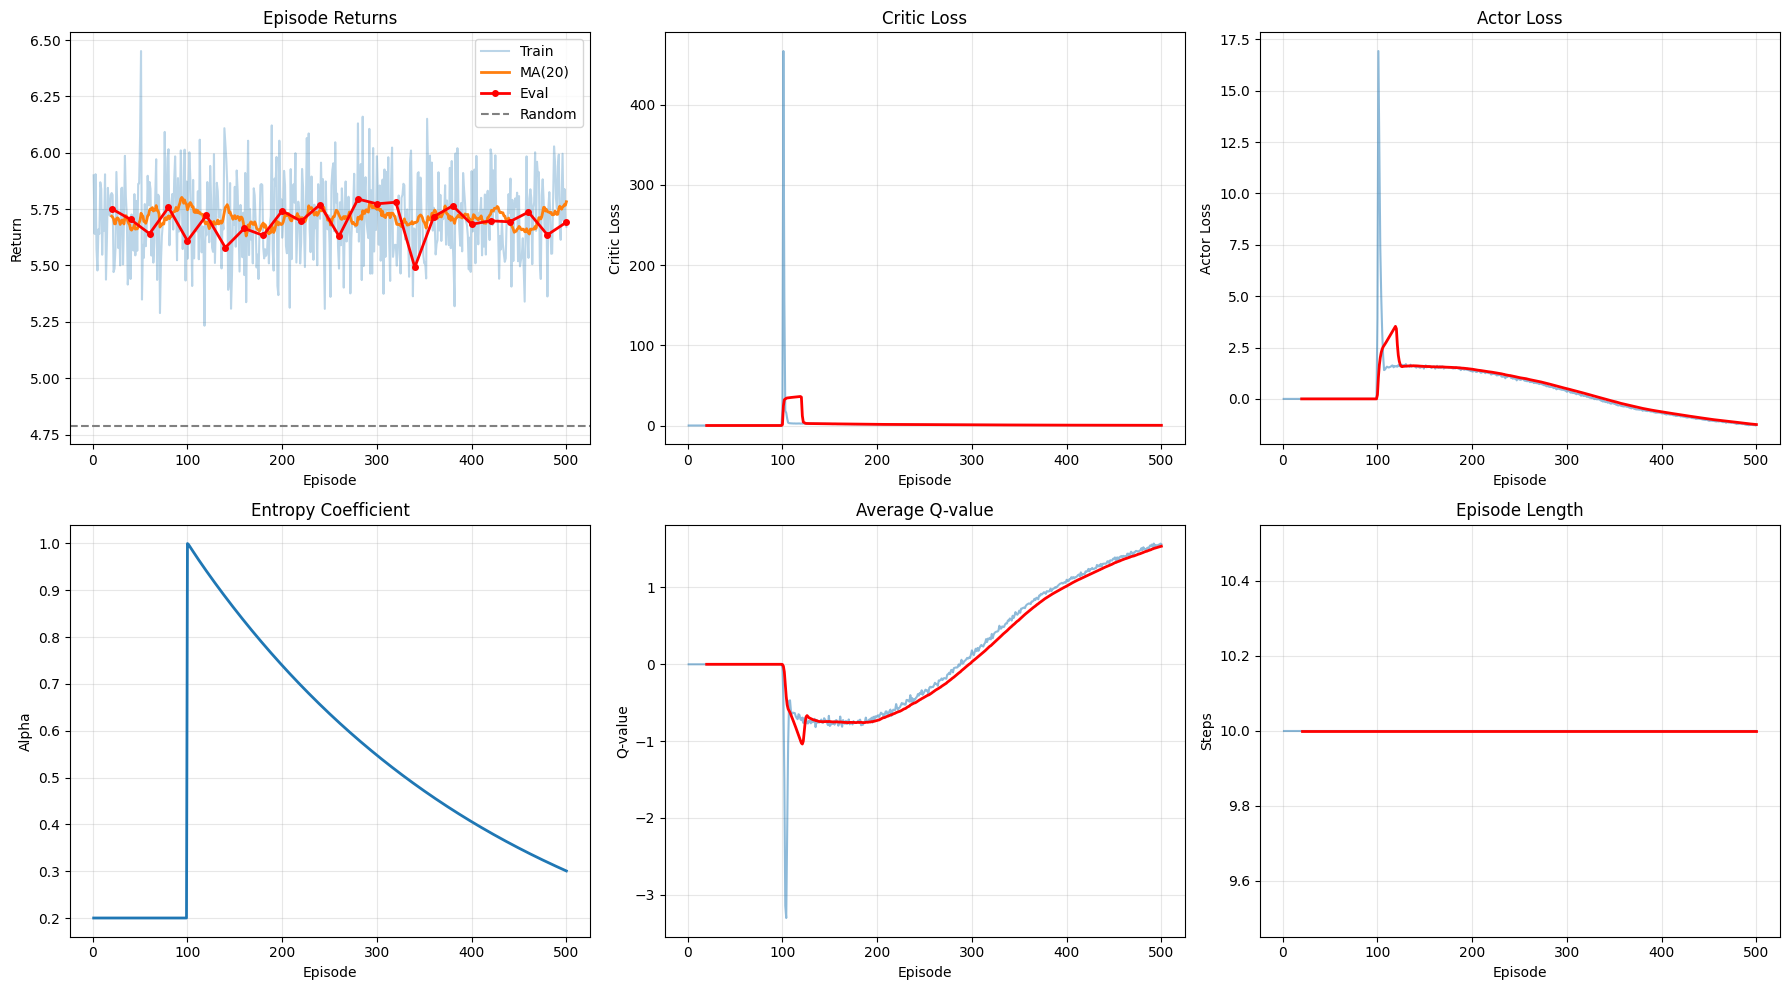

✅ Training curves plotted


In [20]:

# CELL 6: Analyze Training Progress
print("="*60)
print("TRAINING PROGRESS ANALYSIS")
print("="*60)

# Convert to DataFrame
df_metrics = pd.DataFrame(training_metrics)

# Filter out None values from eval_return
df_metrics_eval = df_metrics[df_metrics['eval_return'].notna()]

# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Episode returns
axes[0, 0].plot(df_metrics['episode'], df_metrics['episode_return'], alpha=0.3, label='Train')
axes[0, 0].plot(df_metrics['episode'], df_metrics['episode_return'].rolling(20).mean(),
                linewidth=2, label='MA(20)')
if len(df_metrics_eval) > 0:
    axes[0, 0].plot(df_metrics_eval['episode'], df_metrics_eval['eval_return'],
                    'r-', linewidth=2, label='Eval', marker='o', markersize=4)
axes[0, 0].axhline(random_baseline, color='gray', linestyle='--', label='Random')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Return')
axes[0, 0].set_title('Episode Returns')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Critic loss
axes[0, 1].plot(df_metrics['episode'], df_metrics['critic_loss'], alpha=0.5)
axes[0, 1].plot(df_metrics['episode'], df_metrics['critic_loss'].rolling(20).mean(),
                linewidth=2, color='red')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Critic Loss')
axes[0, 1].set_title('Critic Loss')
axes[0, 1].grid(True, alpha=0.3)

# Actor loss
axes[0, 2].plot(df_metrics['episode'], df_metrics['actor_loss'], alpha=0.5)
axes[0, 2].plot(df_metrics['episode'], df_metrics['actor_loss'].rolling(20).mean(),
                linewidth=2, color='red')
axes[0, 2].set_xlabel('Episode')
axes[0, 2].set_ylabel('Actor Loss')
axes[0, 2].set_title('Actor Loss')
axes[0, 2].grid(True, alpha=0.3)

# Alpha (entropy coefficient)
axes[1, 0].plot(df_metrics['episode'], df_metrics['alpha'], linewidth=2)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Alpha')
axes[1, 0].set_title('Entropy Coefficient')
axes[1, 0].grid(True, alpha=0.3)

# Q-values
axes[1, 1].plot(df_metrics['episode'], df_metrics['q_value'], alpha=0.5)
axes[1, 1].plot(df_metrics['episode'], df_metrics['q_value'].rolling(20).mean(),
                linewidth=2, color='red')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Q-value')
axes[1, 1].set_title('Average Q-value')
axes[1, 1].grid(True, alpha=0.3)

# Episode lengths
axes[1, 2].plot(df_metrics['episode'], df_metrics['episode_length'], alpha=0.5)
axes[1, 2].plot(df_metrics['episode'], df_metrics['episode_length'].rolling(20).mean(),
                linewidth=2, color='red')
axes[1, 2].set_xlabel('Episode')
axes[1, 2].set_ylabel('Steps')
axes[1, 2].set_title('Episode Length')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training curves plotted")



## 7. Test Recommendations
See what models the trained agent recommends.

In [22]:

# CELL 7: Test Recommendations
print("="*60)
print("TESTING AGENT RECOMMENDATIONS")
print("="*60)

# Run one episode and show recommendations
state, _ = env.reset(seed=42)
recommended_indices = []

print("\nStep-by-step recommendations:\n")

for step in range(5):  # Show first 5 steps
    action = agent.select_action(state, evaluate=True)
    state, reward, terminated, truncated, info = env.step(action)

    selected = info['selected_models']
    recommended_indices.extend(selected)

    print(f"Step {step+1}:")
    print(f"  Reward: {reward:.4f}")
    print(f"  Models selected:")

    for idx in selected:
        model_info = env.features_df.iloc[idx]
        print(f"    - {model_info['model_id']}")
        print(f"      Cost: {model_info['cost_score']:.3f}, "
              f"Perf: {model_info['performance_score']:.3f}, "
              f"Pop: {model_info['popularity_score']:.3f}")
    print()

    if terminated or truncated:
        break

print(f"Total models recommended: {len(set(recommended_indices))}")


TESTING AGENT RECOMMENDATIONS

Step-by-step recommendations:

Step 1:
  Reward: 0.7268
  Models selected:
    - Qwen/Qwen2.5-72B-Instruct
      Cost: 0.214, Perf: 1.000, Pop: 0.468
    - Qwen/Qwen3-32B-FP8
      Cost: 0.047, Perf: nan, Pop: 0.335
    - deepseek-ai/DeepSeek-R1
      Cost: 0.047, Perf: 0.690, Pop: 0.776
    - Qwen/Qwen3-8B
      Cost: 0.023, Perf: nan, Pop: 0.785
    - xlnet/xlnet-base-cased
      Cost: nan, Perf: nan, Pop: 0.271

Step 2:
  Reward: 0.4846
  Models selected:
    - Qwen/Qwen2.5-Coder-0.5B-Instruct
      Cost: 0.001, Perf: nan, Pop: 0.616
    - Qwen/Qwen3-32B
      Cost: 0.095, Perf: nan, Pop: 0.759
    - TinyLlama/TinyLlama-1.1B-Chat-v1.0
      Cost: 0.003, Perf: 0.000, Pop: 0.697
    - meta-llama/Meta-Llama-3-8B
      Cost: 0.023, Perf: 0.212, Pop: 0.813
    - meta-llama/Llama-3.2-3B
      Cost: 0.002, Perf: 0.113, Pop: 0.407

Step 3:
  Reward: 0.5691
  Models selected:
    - meta-llama/Llama-3.2-1B-Instruct
      Cost: 0.001, Perf: 0.275, Pop: 0.775
    

## 8. Save Models & Artifacts

In [23]:

# CELL 8: Save Models & Artifacts
print("="*60)
print("SAVING ARTIFACTS")
print("="*60)

# Save training metrics
metrics_df = pd.DataFrame(training_metrics)
metrics_file = paths.RL_MODELS_DIR / "training_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)
print(f"✅ Training metrics saved to: {metrics_file}")

# Save SAC configuration
sac_config = {
    'metadata': {
        'created_at': pd.Timestamp.now().isoformat(),
        'total_episodes': config['num_episodes'],
        'total_steps': total_steps,
        'best_eval_return': float(best_eval_return)
    },
    'hyperparameters': {
        'lr': 3e-4,
        'gamma': 0.99,
        'tau': 0.005,
        'alpha': 0.2,
        'auto_entropy': True,
        'hidden_dim': 256,
        'buffer_size': 100000,
        'batch_size': config['batch_size']
    },
    'architecture': {
        'state_dim': env.observation_space.shape[0],
        'action_dim': env.action_space.shape[0],
        'actor_params': actor_params,
        'critic_params': critic_params,
        'total_params': total_params
    },
    'performance': {
        'random_baseline': random_baseline,
        'trained_mean': float(np.mean(eval_returns)),
        'trained_std': float(np.std(eval_returns)),
        'improvement_pct': float(improvement)
    }
}

config_file = paths.RL_MODELS_DIR / "sac_config.json"
save_json(sac_config, config_file)
print(f"✅ SAC config saved to: {config_file}")

print(f"\n{'='*60}")
print("SPRINT 6 COMPLETE")
print(f"{'='*60}")

print(f"\n✅ Artifacts Created:")
print(f"   1. Best model: {paths.RL_MODELS_DIR / 'sac_best.pt'}")
print(f"   2. Final model: {paths.RL_MODELS_DIR / 'sac_final.pt'}")
print(f"   3. Training metrics: {metrics_file}")
print(f"   4. SAC config: {config_file}")

print(f"\n📊 Final Results:")
print(f"   Random baseline: {random_baseline:.4f}")
print(f"   Trained agent:   {np.mean(eval_returns):.4f} ± {np.std(eval_returns):.4f}")
print(f"   Improvement:     {improvement:+.2f}%")

print(f"\n🎉 Training complete! The agent has learned to recommend LLMs.")
print(f"\nNext: Deploy as API (move to VS Code)")

SAVING ARTIFACTS
✅ Training metrics saved to: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/training_metrics.csv
✅ SAC config saved to: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/sac_config.json

SPRINT 6 COMPLETE

✅ Artifacts Created:
   1. Best model: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/sac_best.pt
   2. Final model: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/sac_final.pt
   3. Training metrics: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/training_metrics.csv
   4. SAC config: /content/drive/MyDrive/llm-recommender-colab/artifacts/rl_models/sac_config.json

📊 Final Results:
   Random baseline: 4.7900
   Trained agent:   5.7330 ± 0.1811
   Improvement:     +19.69%

🎉 Training complete! The agent has learned to recommend LLMs.

Next: Deploy as API (move to VS Code)
